In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df_test_2017 = pd.read_csv('../data/processed/2017/2017_test_scaled.csv')

X_test_2017 = df_test_2017.drop(columns=['Label'])
y_test_2017 = df_test_2017['Label'].values

NB_FEATURES   = X_test_2017.shape[1]
TEST_BATCH_SIZE = 4096

print(f"Test 2017 : {X_test_2017.shape}")
print(f"Distribution labels : {pd.Series(y_test_2017).value_counts().to_dict()}")

Test 2017 : (565576, 49)
Distribution labels : {0: 454265, 1: 111311}


In [3]:
class DuelingQNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 64),         nn.LayerNorm(64),  nn.ReLU(),
            nn.Linear(64, 32),          nn.LayerNorm(32),  nn.ReLU(),
        )
        self.v = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1))
        self.a = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, action_size))

    def forward(self, x):
        x = self.net(x)
        a = self.a(x)
        v = self.v(x)
        return v + (a - a.mean(dim=1, keepdim=True))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

Device : cpu


In [4]:
def evaluate(model_path, X, y_true, label):
    model = DuelingQNetwork(NB_FEATURES, 2).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    y_pred = []
    with torch.no_grad():
        for i in range(0, len(X), TEST_BATCH_SIZE):
            batch = torch.FloatTensor(X.iloc[i:i+TEST_BATCH_SIZE].values).to(device)
            preds = model(batch).argmax(dim=1).cpu().numpy()
            y_pred.extend(preds)

    y_pred = np.array(y_pred)
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred, target_names=['Bénin', 'Attaque']))

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn)
    precision = tp / (tp + fp)
    f1        = 2 * recall * precision / (recall + precision + 1e-9)
    print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
    print(f"Recall   : {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1-Score : {f1:.4f}")

    return y_pred, cm, {'recall': recall, 'precision': precision, 'f1': f1}

In [5]:
pred_p1, cm_p1, metrics_p1 = evaluate(
    '../models/dueling_dqn_2017.pth',
    X_test_2017, y_test_2017,
    'Phase I — dueling_dqn_2017.pth  (référence source)'
)


  Phase I — dueling_dqn_2017.pth  (référence source)
              precision    recall  f1-score   support

       Bénin       1.00      1.00      1.00    454265
     Attaque       0.99      1.00      0.99    111311

    accuracy                           1.00    565576
   macro avg       0.99      1.00      1.00    565576
weighted avg       1.00      1.00      1.00    565576

TN=452,964  FP=1,301  FN=320  TP=110,991
Recall   : 0.9971
Precision: 0.9884
F1-Score : 0.9928


In [6]:
pred_p3, cm_p3, metrics_p3 = evaluate(
    '../models/react_d3qn_2018.pth',
    X_test_2017, y_test_2017,
    'Phase III — react_d3qn_2018.pth  (après adaptation 2018)'
)


  Phase III — react_d3qn_2018.pth  (après adaptation 2018)
              precision    recall  f1-score   support

       Bénin       0.86      0.86      0.86    454265
     Attaque       0.42      0.40      0.41    111311

    accuracy                           0.77    565576
   macro avg       0.64      0.63      0.64    565576
weighted avg       0.77      0.77      0.77    565576

TN=392,264  FP=62,001  FN=66,305  TP=45,006
Recall   : 0.4043
Precision: 0.4206
F1-Score : 0.4123


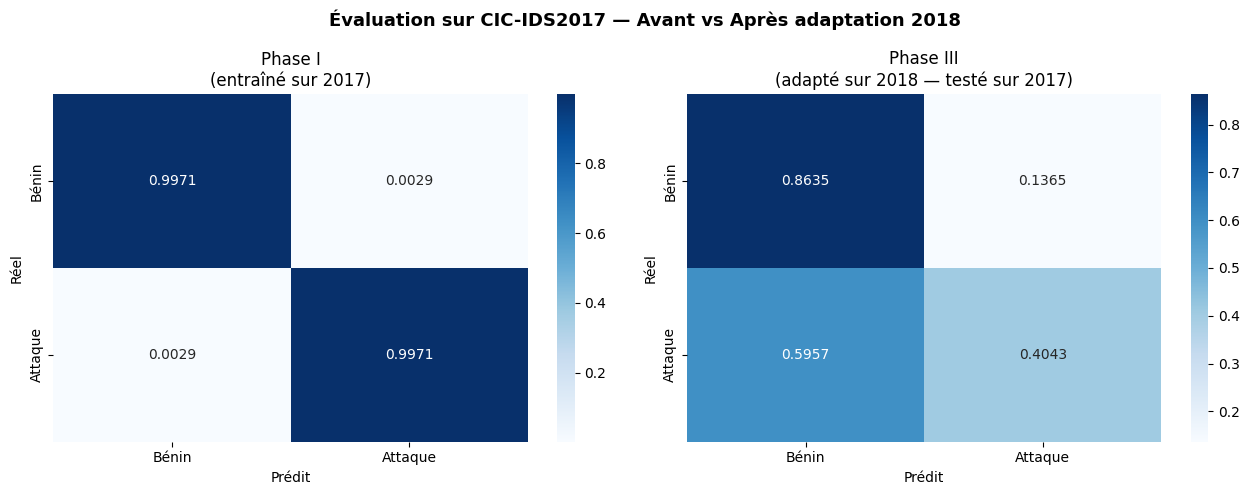

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Évaluation sur CIC-IDS2017 — Avant vs Après adaptation 2018",
             fontsize=13, fontweight='bold')

for ax, cm, title in zip(
    axes,
    [cm_p1, cm_p3],
    ['Phase I\n(entraîné sur 2017)', 'Phase III\n(adapté sur 2018 — testé sur 2017)']
):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt='.4f', cmap='Blues', ax=ax,
        xticklabels=['Bénin', 'Attaque'],
        yticklabels=['Bénin', 'Attaque']
    )
    ax.set_title(title)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.savefig('../figures/forgetting_test_2017.png', dpi=150)
plt.show()

In [9]:
results = pd.DataFrame({
    'Modèle'    : ['Phase I (source)', 'Phase III (après 2018)'],
    'Recall'    : [metrics_p1['recall'],    metrics_p3['recall']],
    'Precision' : [metrics_p1['precision'], metrics_p3['precision']],
    'F1-Score'  : [metrics_p1['f1'],        metrics_p3['f1']],
})

cols = ['Recall', 'Precision', 'F1-Score']
results[cols] = results[cols].apply(lambda s: s.map(lambda x: f"{x:.4f}"))
print("\n" + "="*55)
print("  Résumé — Catastrophic Forgetting Test (sur 2017)")
print("="*55)
print(results.to_string(index=False))

delta_recall = metrics_p3['recall'] - metrics_p1['recall']
delta_f1     = metrics_p3['f1']     - metrics_p1['f1']
print(f"\nΔ Recall  (Phase III - Phase I) : {delta_recall:+.4f}")
print(f"Δ F1-Score (Phase III - Phase I) : {delta_f1:+.4f}")

if abs(delta_recall) < 0.03:
    print("\n Pas d'oubli catastrophique détecté (Δ Recall < 3%)")
elif delta_recall < -0.05:
    print("\n Oubli catastrophique détecté — le modèle a dégradé sur 2017")
else:
    print("\n Légère dégradation, mais dans les limites acceptables")


  Résumé — Catastrophic Forgetting Test (sur 2017)
                Modèle Recall Precision F1-Score
      Phase I (source) 0.9971    0.9884   0.9928
Phase III (après 2018) 0.4043    0.4206   0.4123

Δ Recall  (Phase III - Phase I) : -0.5928
Δ F1-Score (Phase III - Phase I) : -0.5805

 Oubli catastrophique détecté — le modèle a dégradé sur 2017
